In [1]:
import pickle
import statistics

In [2]:
from glob import glob
tif_list = glob('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/train_test_splits/her2st/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
test_slides

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

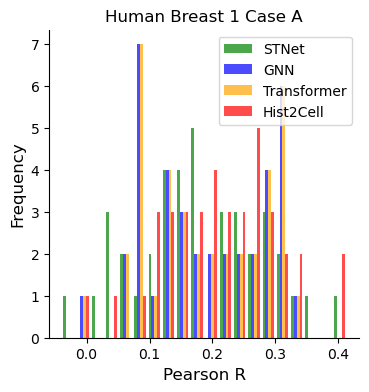

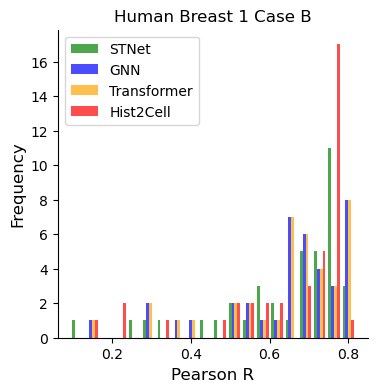

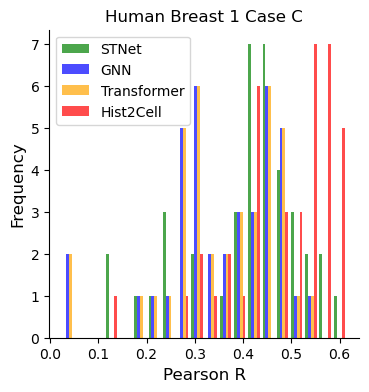

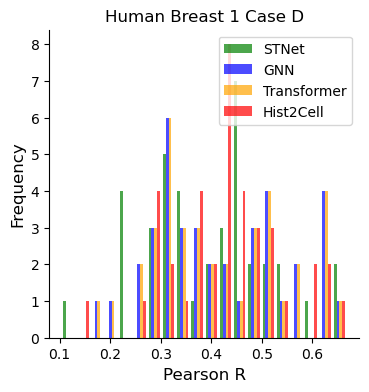

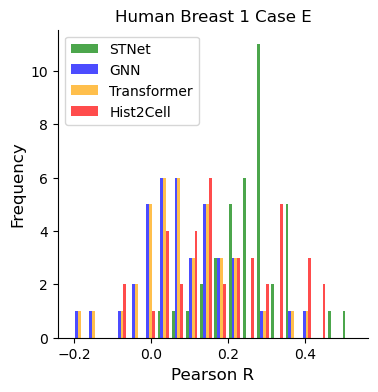

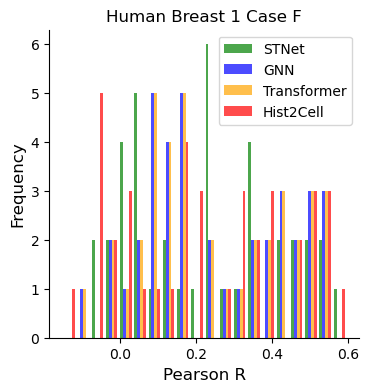

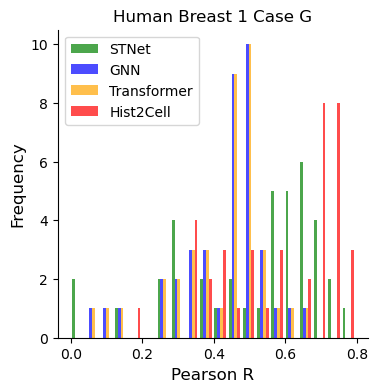

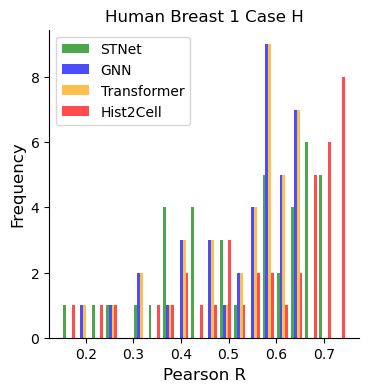

In [3]:
for case in test_slides:

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch100_lr1e-4_2hop_ensemble_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        ensemble_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        gcn_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        trans_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        densenet_cell_pearson_list = pickle.load(f)
        
    import matplotlib.pyplot as plt
    

    # Set up plot aesthetics
    plt.figure(figsize=(4, 4))
    # plt.style.use('seaborn-whitegrid')

    wlist = [
             densenet_cell_pearson_list,
             gcn_cell_pearson_list,
             trans_cell_pearson_list,
             ensemble_cell_pearson_list,
             ]
    colors = ['green', 'blue', 'orange', 'red']
    labels = ['STNet', 'GNN', 'Transformer', 'Hist2Cell']
    
    # Plot histogram
    n_bins = 20
    plt.hist(wlist, bins=n_bins, color=colors, label=labels, alpha=0.7)

    # Set labels and title
    plt.xlabel('Pearson R', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Human Breast 1 Case '+case, fontsize=12)

    # Add legend
    plt.legend(fontsize=10)
    
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Save the plot as an image file
    plt.savefig('histogram_' + case + '.png', dpi=300)

    # Display the plot
    plt.show()
    

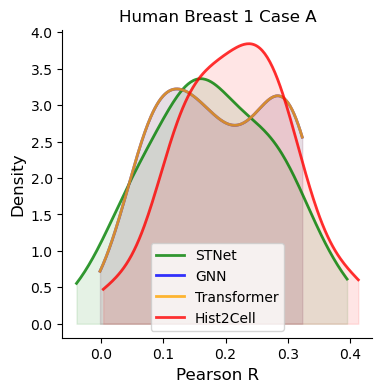

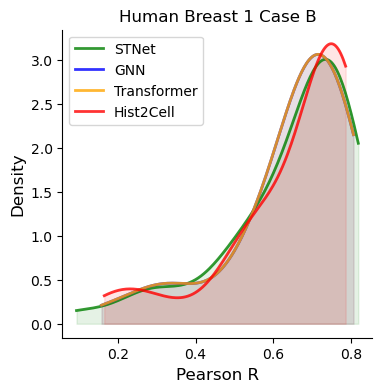

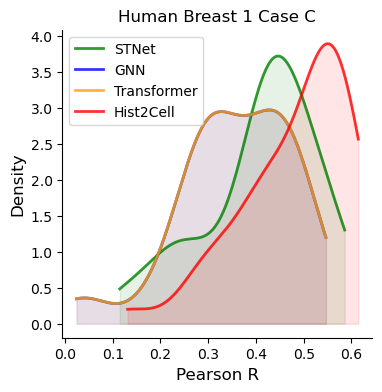

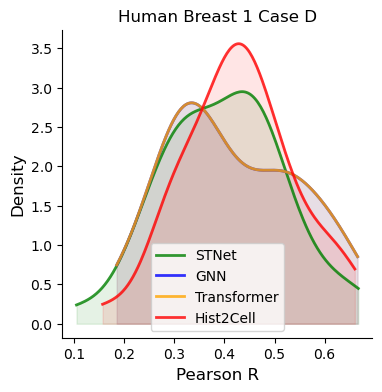

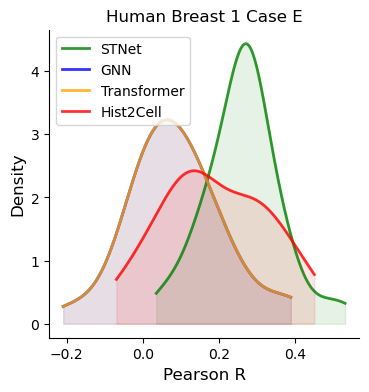

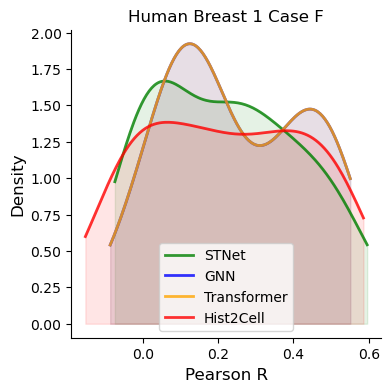

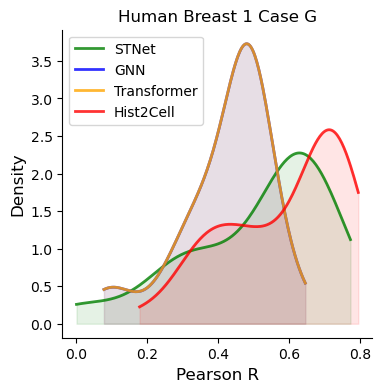

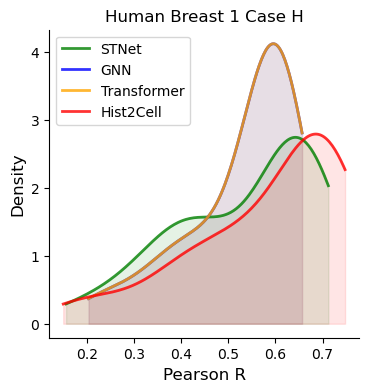

In [4]:
from scipy.stats import gaussian_kde
import numpy as np

for case in test_slides:
    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch100_lr1e-4_2hop_ensemble_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        ensemble_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        gcn_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        trans_cell_pearson_list = pickle.load(f)

    with open('/home/r15user3/Documents/shared_project/Hist2Cell/code/training/pearson_log/her2st_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        densenet_cell_pearson_list = pickle.load(f)

    # Set up plot aesthetics
    plt.figure(figsize=(4, 4))
    # plt.style.use('seaborn-whitegrid')

    wlist = [
             densenet_cell_pearson_list,
             gcn_cell_pearson_list,
             trans_cell_pearson_list,
             ensemble_cell_pearson_list,
             ]
    colors = ['green', 'blue', 'orange', 'red']
    labels = ['STNet', 'GNN', 'Transformer', 'Hist2Cell']

    # Plot KDE with shadow
    for i in range(len(wlist)):
        density = gaussian_kde(wlist[i])
        xs = np.linspace(min(wlist[i]), max(wlist[i]), 200)
        plt.plot(xs, density(xs), color=colors[i], label=labels[i], alpha=0.8, linewidth=2, zorder=3)
        plt.fill_between(xs, density(xs), alpha=0.1, color=colors[i], zorder=2)

    # Set labels and title
    plt.xlabel('Pearson R', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Human Breast 1 Case '+case, fontsize=12)

    # Add legend
    plt.legend(fontsize=10)

    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Save the plot as an image file
    plt.savefig('density_' + case + '.png', dpi=300)

    # Display the plot
    plt.show()

In [2]:
import pickle
import statistics

from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/her2st/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
test_slides

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

In [5]:
import numpy as np

all_pearson_list = list()
for case in test_slides:
    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/her2st_selectedlr_cluster10_leave_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        cell_pearson_list = pickle.load(f)
        all_pearson_list.append(cell_pearson_list)

In [9]:
all_pearson_array = np.array(all_pearson_list)

In [12]:
np.mean(all_pearson_array, axis=1)

array([0.06877183, 0.21205539, 0.21094226, 0.16937469, 0.11584723,
       0.07236369, 0.24340578, 0.22651975])

In [13]:
np.mean(all_pearson_array)

0.16491007651264789

In [14]:
positive_pearson_array = all_pearson_array[all_pearson_array > 0]
positive_pearson_array

array([0.02545036, 0.12874222, 0.03316279, 0.17602928, 0.03580755,
       0.09030244, 0.21584197, 0.0457768 , 0.39034843, 0.03281703,
       0.26468745, 0.22735113, 0.15974283, 0.07315997, 0.47279631,
       0.00926401, 0.21249829, 0.2778884 , 0.27287291, 0.20127572,
       0.21702723, 0.30153712, 0.20078081, 0.25527335, 0.16170301,
       0.07218461, 0.22284648, 0.20392136, 0.20166168, 0.10917176,
       0.22149576, 0.31582678, 0.22708608, 0.13901312, 0.09589728,
       0.03053519, 0.26167834, 0.09138088, 0.09341309, 0.21921619,
       0.17013673, 0.10854394, 0.00253281, 0.07413119, 0.04638955,
       0.10007448, 0.26307611, 0.08095819, 0.0915731 , 0.11804429,
       0.07339598, 0.12795568, 0.12843496, 0.07733573, 0.00976256,
       0.02071836, 0.06515324, 0.01126299, 0.3565378 , 0.31893744,
       0.29723055, 0.50750719, 0.10343975, 0.12632853, 0.10828465,
       0.08716255, 0.4920006 , 0.03662872, 0.29235185, 0.09796636,
       0.24606184, 0.35862313, 0.17057677, 0.28013794, 0.26283

In [15]:
np.mean(positive_pearson_array)

0.17230696236870577

In [19]:
len(positive_pearson_array)/80

0.9625

In [20]:
len(positive_pearson_array)

77